In [1]:
import duckdb

from networks.comment_108 import Comment108Model
import shutil
import pandas as pd

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, fractions,boundaries,interpretation,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,igm,iga,label as raw_label
                 FROM protein_data
                 WHERE observation_nr = 1
                 """).df()
con.close()

patterns = ['m-komponent < 1 g/l', 'specifik immunisering', 'lätt avvikande immunglobulinfördelning', 'lätt avavikande immunglobulinfördelning']

def has_valid_text(text):
    text_lower = str(text).lower()
    return any(p in text_lower for p in patterns)

df = df[df['raw_label'].isin([0, 2])].copy()

correct_label = df['raw_label'] == 2
valid_text = df['interpretation'].apply(has_valid_text)

df['label'] = ((correct_label) | (valid_text)).astype(int)


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

extra_val = train_rows.sample(frac=0.2, random_state=42)
train_rows = train_rows.drop(extra_val.index)
val_rows = pd.concat([val_rows, extra_val], ignore_index=True)

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan kommentar 108 i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med kommentar 108 i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")
print(f"-----\nAntal utan kommentar 108 i valideringsdatan: {len(val_rows[val_rows['label'] == 0])}")
print(f"Antal med kommenta r108 i valideringsdatan: {len(val_rows[val_rows['label'] == 1])}")


cnn = Comment108Model()
train_dl,val_dl,test_dl = cnn.build_dataloaders(train_rows,val_rows,test_rows)


results = []

best_auc = -1
best_run = None

for run in range(10):
    print(f"Körning {run+1}/10")

    cnn = Comment108Model()

    auc = cnn.retrain(
        train_dl=train_dl,
        val_dl=val_dl,
        patience=10,
        model_path=f"../models/tmp_comment108_run{run}.pth"
    )

    results.append({
        "run": run + 1,
        "val_auc": auc
    })

    if auc > best_auc:
        best_auc = auc
        best_run = run + 1

        shutil.copy(
            f"../models/tmp_comment108_run{run}.pth",
            cnn.model_path
        )

result_df = pd.DataFrame(results)
result_df.to_csv("../results/comment108_runs.csv", index=False)

print(result_df)
print(f"Bästa körning: {best_run}")
print(f"Bästa val AUC: {best_auc:.4f}")

Antal utan kommentar 108 i träningsdatan: 14122
Antal med kommentar 108 i träningsdatan: 2389
-----
Antal utan kommentar 108 i valideringsdatan: 14882
Antal med kommenta r108 i valideringsdatan: 730
Körning 1/10
  -> ny bästa modell sparad till ../models/tmp_comment108_run0.pth
Epoch   0 | train: 0.6850 | val: 0.6852 | acc: 53.62% | AUC: 0.674  | LR: 0.001
  -> ny bästa modell sparad till ../models/tmp_comment108_run0.pth
Epoch   1 | train: 0.6447 | val: 0.5938 | acc: 71.14% | AUC: 0.692  | LR: 0.001
  -> ny bästa modell sparad till ../models/tmp_comment108_run0.pth
Epoch   2 | train: 0.6280 | val: 0.5997 | acc: 71.40% | AUC: 0.704  | LR: 0.001
  -> ny bästa modell sparad till ../models/tmp_comment108_run0.pth
Epoch   3 | train: 0.6161 | val: 0.5504 | acc: 78.59% | AUC: 0.731  | LR: 0.001
  -> ny bästa modell sparad till ../models/tmp_comment108_run0.pth
Epoch   4 | train: 0.5836 | val: 0.5542 | acc: 73.69% | AUC: 0.789  | LR: 0.001
  -> ny bästa modell sparad till ../models/tmp_commen

In [ ]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, fractions,boundaries,interpretation,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,igm,iga,label as raw_label
                 FROM protein_data
                 WHERE observation_nr = 1
                 """).df()
con.close()

patterns = ['m-komponent < 1 g/l', 'specifik immunisering', 'lätt avvikande immunglobulinfördelning', 'lätt avavikande immunglobulinfördelning']

def has_valid_text(text):
    text_lower = str(text).lower()
    return any(p in text_lower for p in patterns)

df = df[df['raw_label'].isin([0, 2])].copy()

correct_label = df['raw_label'] == 2
valid_text = df['interpretation'].apply(has_valid_text)

df['label'] = ((correct_label) | (valid_text)).astype(int)


kfold_rows = df[df['set'].isin(['train','val']) ].copy()

drop_indices = kfold_rows[kfold_rows['label'] == 0].sample(frac=0.7).index

kfold_rows = kfold_rows.drop(drop_indices)

print(f"Antal utan kommentar 108 i datan: {len(kfold_rows[kfold_rows['label'] == 0])}")
print(f"Antal med kommentar 108 i datan: {len(kfold_rows[kfold_rows['label'] == 1])}")

cnn = Comment108Model()
cnn.retrain_with_k_fold(kfold_rows)

Antal utan kommentar 108 i datan: 18587
Antal med kommentar 108 i datan: 3119
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   0 | train: 0.6775 | val: 0.6299 | acc: 70.11% | AUC: 0.721  | LR: 0.001
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   1 | train: 0.5907 | val: 0.5314 | acc: 70.34% | AUC: 0.816  | LR: 0.001
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   2 | train: 0.4636 | val: 0.4326 | acc: 74.34% | AUC: 0.889  | LR: 0.001
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   3 | train: 0.3998 | val: 0.4054 | acc: 75.68% | AUC: 0.902  | LR: 0.001
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   4 | train: 0.3654 | val: 0.3739 | acc: 81.58% | AUC: 0.908  | LR: 0.001
  -> ny bästa modell sparad till ../models/comment_108_fold1.pth
Epoch   5 | train: 0.3532 | val: 0.3675 | acc: 84.34% | AUC: 0.912  | LR: 0.001

,fold,train_loss,val_loss,val_accuracy,val_auc
0,1,0.230019,0.420320,87.563335,0.921029
1,2,0.210694,0.459192,87.471211,0.911431
2,3,0.337885,0.410222,84.615385,0.921653
3,4,0.256006,0.366142,85.674804,0.920287
4,5,0.256724,0.327970,81.713496,0.932715
5,6,0.366313,0.438773,81.022570,0.909256
6,7,0.254316,0.336856,85.345622,0.928920
7,8,0.286005,0.363871,81.658986,0.916182
8,9,0.262985,0.354717,86.866359,0.922182
9,10,0.240030,0.362230,83.732719,0.914596


Totala mängd datapunkter: 15612
              precision    recall  f1-score   support

     Negativ       0.99      0.89      0.94     14882
     Positiv       0.26      0.79      0.39       730

    accuracy                           0.89     15612
   macro avg       0.62      0.84      0.66     15612
weighted avg       0.95      0.89      0.91     15612

[[13237  1645]
 [  150   580]]
AUC: 0.9223090135550348
Accuracy:  88.50%
FN-rate:   20.55%  (farliga missade fall)
FP-rate:   11.05%  (onödiga larm)
Sensitivitet:   79.45%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   88.95%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9223


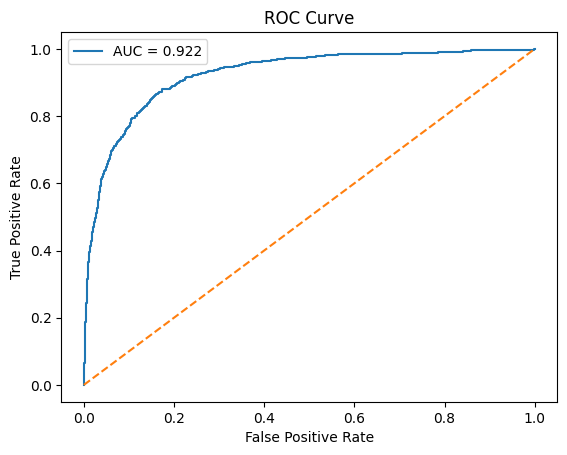

In [ ]:
result = cnn.predict(test_rows)
result = cnn.evaluate(val_rows,threshold=0.5)

